# Currency Stress / Stablecoin Substitution Risk Index

Composite stress score based on:
- **z(12m FX depreciation vs USD)**
- **z(3m realized FX volatility)**
- **z(CPI inflation YoY)**
- **z(5y sovereign CDS spread)**

Countries ranked by percentile — top decile = acute stress.

In [1]:
# ── 0. Install / imports ──────────────────────────────────────────────────────
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')
BASE_PATH = Path("/content/drive/MyDrive/Yield Curve Surfers/Data/Bloomberg data")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

FILE = BASE_PATH / "Countrydata_riskindicator.xlsx"

In [3]:
# ── 1. Load raw sheet ─────────────────────────────────────────────────────────
raw = pd.read_excel(FILE, sheet_name='Sheet1', header=None)

# Row 0 → data type  (Currency / CDS / CPI)
# Row 1 → country name
# Row 2 → description
# Row 3 → ticker
# Row 4 → field (PX_LAST etc.)
# Row 5+ → data  (col 0 = date)

dtype_row   = raw.iloc[0]
country_row = raw.iloc[1]
dates       = pd.to_datetime(raw.iloc[5:, 0], errors='coerce')
data_block  = raw.iloc[5:, 1:].copy()
data_block.columns = range(data_block.shape[1])
data_block.index   = dates
data_block = data_block.apply(pd.to_numeric, errors='coerce')

print(f"Date range: {dates.min().date()} → {dates.max().date()}")
print(f"Columns: {data_block.shape[1]}")

Date range: 2019-01-01 → 2026-02-20
Columns: 57


In [5]:
# ── 2. Split into FX / CDS / CPI blocks ──────────────────────────────────────
col_idx = pd.DataFrame({
    'dtype':   dtype_row.iloc[1:].values,
    'country': country_row.iloc[1:].values
})
col_idx.index = range(data_block.shape[1])

fx_cols  = col_idx[col_idx['dtype'] == 'Currency']
cds_cols = col_idx[col_idx['dtype'] == 'CDS']
cpi_cols = col_idx[col_idx['dtype'] == 'CPI']

# Helper: build a tidy DataFrame for each block
def build_block(cols_meta, label):
    df = data_block[cols_meta.index].copy()
    df.columns = cols_meta['country'].values
    df.index.name = 'date'
    return df

fx_df  = build_block(fx_cols,  'FX')
cds_df = build_block(cds_cols, 'CDS')
cpi_df = build_block(cpi_cols, 'CPI')

# USD is the base — drop it from FX analysis (it's the BBDXY index, col 0)
# Keep only non-USD FX pairs
# First column is 'US' (BBDXY) — remove it
fx_df = fx_df.drop(columns=['US'], errors='ignore')

print("FX countries: ",  list(fx_df.columns))
print("CDS countries:", list(cds_df.columns))
print("CPI countries:", list(cpi_df.columns))

FX countries:  ['India', 'Pakistan', 'Philippines', 'Brazil', 'Indonesia', 'Vietnam', 'Korea', 'Japan', 'Ukraine', 'Venezuela', 'Nigeria', 'Russia', 'Thailand', 'Turkey', 'UK', 'Argentina', 'Mexico', 'Egypt']
CDS countries: ['India', 'US', 'Pakistan', 'Philippines', 'Brazil', 'Indonesia', 'Vietnam', 'Korea', 'Japan', 'Ukraine', 'Venezuela', 'Nigeria', 'Russia', 'Thailand', 'Turkey', 'UK', 'Argentina', 'Mexico', 'Egypt']
CPI countries: ['India', 'US', 'Pakistan', 'Philippines', 'Brazil', 'Indonesia', 'Vietnam CPI All Groups Component YoY 2024=100', 'Korea', 'Japan', 'Ukraine', 'Venezuela', 'Nigeria', 'Russia', 'Thailand', 'Turkey', 'UK', 'Argentina', 'Mexico', 'Egypt']


In [6]:
# ── 3. Resample to monthly (last observation) ─────────────────────────────────
fx_m  = fx_df.resample('ME').last()
cds_m = cds_df.resample('ME').last()
cpi_m = cpi_df.resample('ME').last()

print("Monthly rows:", len(fx_m))

Monthly rows: 86


In [7]:
# ── 4. Compute components ─────────────────────────────────────────────────────

# 4a. 12-month FX depreciation vs USD
#     Higher USD/local = weaker local currency → positive = more stress
fx_depr_12m = fx_m.pct_change(12) * 100  # % depreciation

# 4b. 3-month realised FX volatility (annualised, from daily data)
fx_daily_ret = fx_df.pct_change()
fx_vol_3m = fx_daily_ret.rolling(63).std() * np.sqrt(252) * 100  # annualised %
fx_vol_3m_m = fx_vol_3m.resample('ME').last()

# 4c. CPI YoY inflation (already in % terms in the data)
cpi_yoy = cpi_m.copy()

# 4d. 5y sovereign CDS spread (already in bps in the data)
cds_spread = cds_m.copy()

print("Components computed.")

Components computed.


In [8]:
# ── 5. Align countries present across all four components ─────────────────────
# We need a common country list and a common date index

# Normalise column names (strip whitespace)
for df_ in [fx_depr_12m, fx_vol_3m_m, cpi_yoy, cds_spread]:
    df_.columns = df_.columns.str.strip()

countries_all = (
    set(fx_depr_12m.columns) &
    set(fx_vol_3m_m.columns) &
    set(cpi_yoy.columns) &
    set(cds_spread.columns)
)
# Sort for reproducibility
countries = sorted(countries_all)
print(f"{len(countries)} countries with all four components: {countries}")

# Align date index
common_idx = (
    fx_depr_12m.index
    .intersection(fx_vol_3m_m.index)
    .intersection(cpi_yoy.index)
    .intersection(cds_spread.index)
)

A = fx_depr_12m.loc[common_idx, countries]
B = fx_vol_3m_m.loc[common_idx, countries]
C = cpi_yoy.loc[common_idx,     countries]
D = cds_spread.loc[common_idx,  countries]

17 countries with all four components: ['Argentina', 'Brazil', 'Egypt', 'India', 'Indonesia', 'Japan', 'Korea', 'Mexico', 'Nigeria', 'Pakistan', 'Philippines', 'Russia', 'Thailand', 'Turkey', 'UK', 'Ukraine', 'Venezuela']


In [9]:
# ── 6. Z-score each component cross-sectionally (across countries, per date) ──
#       This gives a relative stress score vs the peer group at each point in time.

def cross_section_zscore(df):
    """Z-score across countries for each date row."""
    mu  = df.mean(axis=1)
    sig = df.std(axis=1)
    return df.sub(mu, axis=0).div(sig, axis=0)

zA = cross_section_zscore(A)   # FX depreciation
zB = cross_section_zscore(B)   # FX volatility
zC = cross_section_zscore(C)   # CPI inflation
zD = cross_section_zscore(D)   # CDS spread

# Equal-weight composite
stress = (zA + zB + zC + zD) / 4
stress.index.name = 'date'

print("Stress index shape:", stress.shape)
stress.tail(3)

Stress index shape: (86, 17)


,Argentina,Brazil,Egypt,India,Indonesia,Japan,Korea,Mexico,Nigeria,Pakistan,Philippines,Russia,Thailand,Turkey,UK,Ukraine,Venezuela
date,,,,,,,,,,,,,,,,,
2025-12-31,1.347664,-0.104826,-0.321570,-0.221475,-0.307790,-0.097303,-0.146101,-0.412356,-0.263152,-0.439125,-0.242491,0.154162,-0.352372,0.141016,-0.340579,0.738525,NaN
2026-01-31,0.954101,0.018334,-0.340987,-0.209432,-0.337385,-0.022331,-0.042133,-0.401975,-0.336917,-0.553835,-0.309248,0.394235,-0.261762,0.085450,-0.331808,0.832971,NaN
2026-02-28,0.753498,-0.056813,-0.314990,-0.174972,-0.354803,0.065270,-0.061923,-0.407636,-0.261475,-0.578637,-0.330353,0.508212,-0.283137,0.055413,-0.278889,0.857720,NaN


In [10]:
# ── 7. Percentile rank across countries (latest snapshot) ─────────────────────
latest = stress.iloc[-1].sort_values(ascending=False)
latest_pct = stress.iloc[-1].rank(pct=True).sort_values(ascending=False) * 100

snapshot = pd.DataFrame({
    'Stress Score': latest,
    'Percentile':   latest_pct
}).sort_values('Percentile', ascending=False)

snapshot['Risk Tier'] = pd.cut(
    snapshot['Percentile'],
    bins=[0, 25, 50, 75, 90, 100],
    labels=['Low', 'Moderate', 'Elevated', 'High', 'Acute']
)

print(f"\n=== Currency Stress Snapshot ({stress.index[-1].date()}) ===")
print(snapshot.to_string())


=== Currency Stress Snapshot (2026-02-28) ===
             Stress Score  Percentile Risk Tier
Ukraine          0.857720      100.00     Acute
Argentina        0.753498       93.75     Acute
Russia           0.508212       87.50      High
Japan            0.065270       81.25      High
Turkey           0.055413       75.00  Elevated
Brazil          -0.056813       68.75  Elevated
Korea           -0.061923       62.50  Elevated
India           -0.174972       56.25  Elevated
Nigeria         -0.261475       50.00  Moderate
UK              -0.278889       43.75  Moderate
Thailand        -0.283137       37.50  Moderate
Egypt           -0.314990       31.25  Moderate
Philippines     -0.330353       25.00       Low
Indonesia       -0.354803       18.75       Low
Mexico          -0.407636       12.50       Low
Pakistan        -0.578637        6.25       Low
Venezuela             NaN         NaN       NaN


KeyError: nan

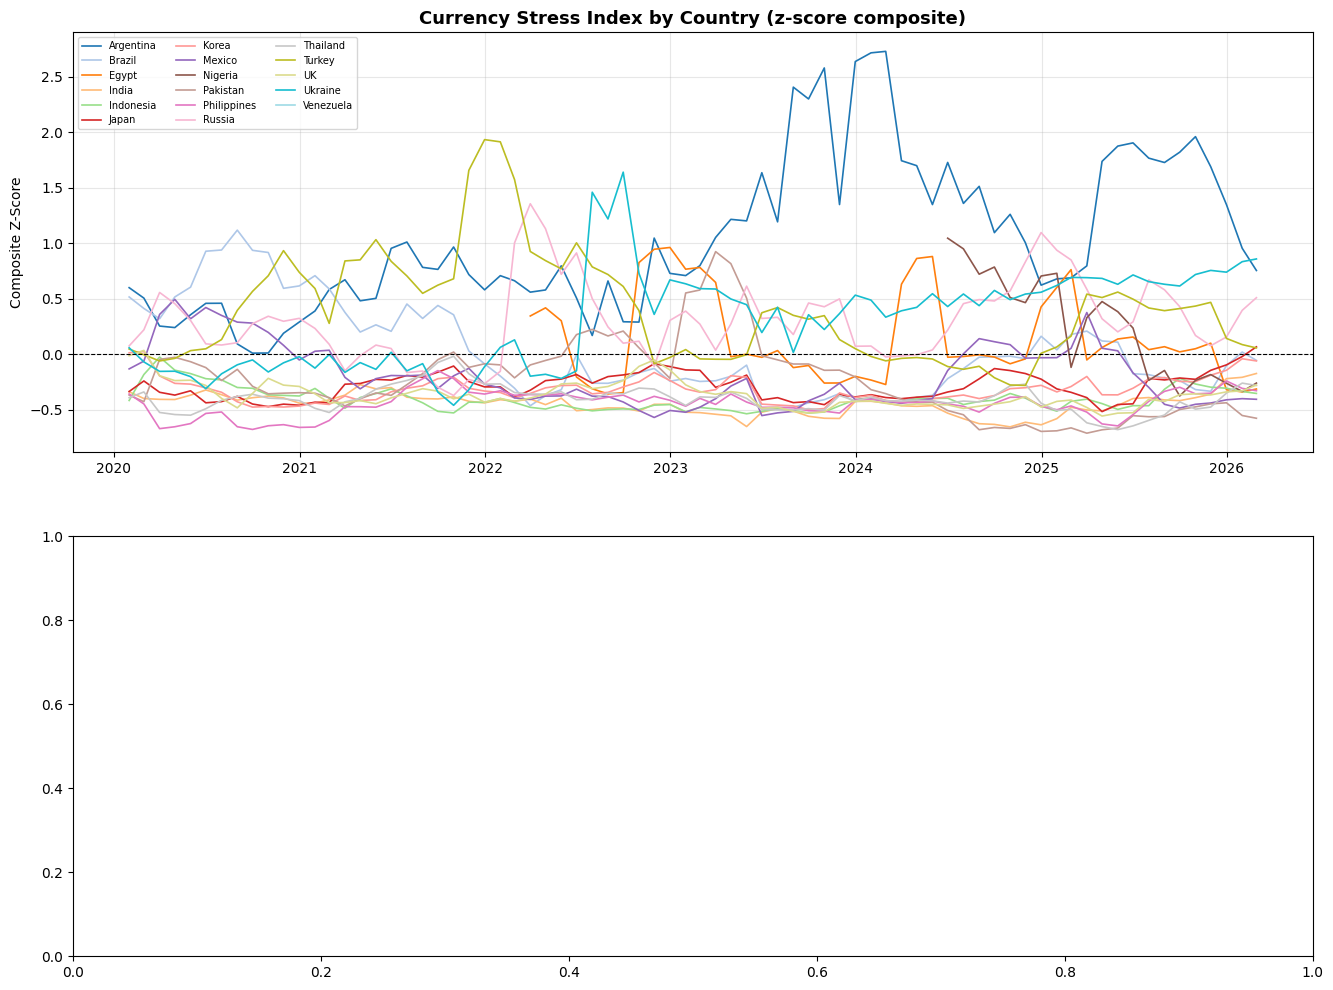

In [11]:
# ── 8. Plot: heatmap of stress over time ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 8a. Time-series stress index per country
ax1 = axes[0]
colors = cm.tab20(np.linspace(0, 1, len(countries)))
for col, c in zip(stress.columns, colors):
    ax1.plot(stress.index, stress[col], label=col, color=c, linewidth=1.2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Currency Stress Index by Country (z-score composite)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Composite Z-Score')
ax1.legend(loc='upper left', ncol=3, fontsize=7)
ax1.grid(alpha=0.3)

# 8b. Horizontal bar chart of latest snapshot
ax2 = axes[1]
tier_colors = {'Acute': '#d32f2f', 'High': '#f57c00', 'Elevated': '#fbc02d',
               'Moderate': '#388e3c', 'Low': '#1976d2'}
bar_colors = [tier_colors[t] for t in snapshot['Risk Tier']]
bars = ax2.barh(snapshot.index, snapshot['Stress Score'], color=bar_colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'Latest Stress Score ({stress.index[-1].date()}) — coloured by Risk Tier',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Composite Z-Score')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Legend for tiers
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in tier_colors.items()]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(BASE_PATH / 'currency_stress_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive.")

In [12]:
# ── 9. Component breakdown for latest date ────────────────────────────────────
breakdown = pd.DataFrame({
    'FX Depr 12m (z)': zA.iloc[-1],
    'FX Vol 3m (z)':   zB.iloc[-1],
    'CPI YoY (z)':     zC.iloc[-1],
    'CDS Spread (z)':  zD.iloc[-1],
    'Composite Score': stress.iloc[-1],
    'Percentile':      stress.iloc[-1].rank(pct=True) * 100
}).loc[snapshot.index]  # sort by descending stress

print("\n=== Component Breakdown (latest) ===")
print(breakdown.round(2).to_string())


=== Component Breakdown (latest) ===
             FX Depr 12m (z)  FX Vol 3m (z)  CPI YoY (z)  CDS Spread (z)  Composite Score  Percentile
Ukraine                 0.40          -0.28        -0.26            3.57             0.86      100.00
Argentina               2.50           0.28         0.13            0.11             0.75       93.75
Russia                 -1.10           2.22        -0.28            1.19             0.51       87.50
Japan                   0.31           0.73        -0.35           -0.44             0.07       81.25
Turkey                  1.74          -1.41         0.11           -0.22             0.06       75.00
Brazil                 -0.93           1.41        -0.38           -0.32            -0.06       68.75
Korea                  -0.01           0.54        -0.34           -0.44            -0.06       62.50
India                   0.40          -0.34        -0.33           -0.43            -0.17       56.25
Nigeria                -0.79           0.01 

In [13]:
# ── 10. Export results to Excel ───────────────────────────────────────────────
out_path = BASE_PATH / 'currency_stress_results.xlsx'

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    snapshot.to_excel(writer, sheet_name='Latest_Snapshot')
    breakdown.round(3).to_excel(writer, sheet_name='Component_Breakdown')
    stress.round(3).to_excel(writer, sheet_name='Stress_Timeseries')
    zA.round(3).to_excel(writer, sheet_name='z_FX_Depreciation')
    zB.round(3).to_excel(writer, sheet_name='z_FX_Volatility')
    zC.round(3).to_excel(writer, sheet_name='z_CPI_Inflation')
    zD.round(3).to_excel(writer, sheet_name='z_CDS_Spread')

print(f"Results exported to: {out_path}")

Results exported to: /content/drive/MyDrive/Yield Curve Surfers/Data/Bloomberg data/currency_stress_results.xlsx
